In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from scipy import stats
import seaborn as sns
import SimpleITK as sitk

import warnings
warnings.filterwarnings("ignore", message="Polyfit may be poorly conditioned")

In [53]:
dfs = []
scans = []
root_dir = '/Users/jacob_kitz/frequency_csvs/medium_bottom'

for dirpath, dirnames, filenames in os.walk(root_dir):
    for file in filenames:
        if file == 'stats.csv':
            try:
                
                path = os.path.join(dirpath, file)
                df = pd.read_csv(path)
                
                # relative path from root
                rel = os.path.relpath(dirpath, root_dir)
                parts = rel.split(os.sep)
                
                df['mod_pair'] = parts[0]  # top-level folder under root
                
                # scan folder name
                scan_name = parts[1] if len(parts) > 1 else parts[0]
                
                # parse fields
                matrix = int(scan_name.split('_')[0])
                dfov_match = re.search(r'DFOV_(\d+)', scan_name)
                dfov = int(dfov_match.group(1)) if dfov_match else None
                recon = "IR3" if "IR3" in scan_name else "FBP"
                resampled = 1 if "resampled" in scan_name else 0
                
                # add to dataframe
                df['matrix'] = matrix
                df['dfov'] = dfov
                df['ir'] = recon
                df['resampled'] = resampled
                df['image_path'] = os.path.join(dirpath, "image_bp.nii.gz") # append image path so we can read in while plotting
                dfs.append(df)

            except Exception as e:
                print(f"Failed to read {dirpath}: {e}")

# combine all CSVs
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head(25)

,name,slice,fxmax,fymax,aR,aA,aI,aJ,bR,bA,...,size,bpe,lpe,ef,mod_pair,matrix,dfov,ir,resampled,image_path
0,1024_DFOV_450.nii.gz,953,1.137780,1.137780,63.4,185.3,367,494,59.8,186.2,...,16,6.646600e+07,5.043330e+09,0.013008,0.3_0.6,1024,450,FBP,0,/Users/jacob_kitz/frequency_csvs/medium_bottom...
1,1024_DFOV_500_resampled.nii.gz,953,1.024000,1.024000,63.4,185.3,382,496,59.8,186.2,...,15,1.356210e+08,3.463060e+09,0.037686,0.3_0.6,1024,500,FBP,1,/Users/jacob_kitz/frequency_csvs/medium_bottom...
2,512_DFOV_300_resampled.nii.gz,953,0.512000,0.512000,63.4,185.3,191,248,59.8,186.2,...,6,6.083880e+06,6.309270e+07,0.087947,0.3_0.6,512,300,FBP,1,/Users/jacob_kitz/frequency_csvs/medium_bottom...
3,1024_DFOV_200.nii.gz,953,2.560000,2.560000,63.4,185.3,187,472,59.8,186.2,...,36,1.287740e+09,1.365970e+11,0.009339,0.3_0.6,1024,200,FBP,0,/Users/jacob_kitz/frequency_csvs/medium_bottom...
4,1024_DFOV_500_IR3_resampled.nii.gz,953,1.024000,1.024000,63.4,185.3,382,496,59.8,186.2,...,15,1.206970e+08,3.333530e+09,0.034942,0.3_0.6,1024,500,IR3,1,/Users/jacob_kitz/frequency_csvs/medium_bottom...
5,1024_DFOV_450_IR3_resampled.nii.gz,953,1.024000,1.024000,63.4,185.3,331,444,59.8,186.2,...,15,1.452890e+08,3.228660e+09,0.043062,0.3_0.6,1024,450,IR3,1,/Users/jacob_kitz/frequency_csvs/medium_bottom...
6,512_DFOV_500_IR3.nii.gz,953,0.512000,0.512000,63.4,185.3,191,248,59.8,186.2,...,6,6.496940e+06,6.030720e+07,0.097254,0.3_0.6,512,500,IR3,0,/Users/jacob_kitz/frequency_csvs/medium_bottom...
7,1024_DFOV_200_IR3_resampled.nii.gz,953,1.024000,1.024000,63.4,185.3,75,189,59.8,186.2,...,15,1.164850e+08,3.222480e+09,0.034887,0.3_0.6,1024,200,IR3,1,/Users/jacob_kitz/frequency_csvs/medium_bottom...
8,1024_DFOV_350_IR3_resampled.nii.gz,953,1.024000,1.024000,63.4,185.3,228,342,59.8,186.2,...,16,3.434450e+07,4.467750e+09,0.007629,0.3_0.6,1024,350,IR3,1,/Users/jacob_kitz/frequency_csvs/medium_bottom...
9,512_DFOV_350.nii.gz,953,0.731429,0.731429,63.4,185.3,163,244,59.8,186.2,...,10,1.569880e+07,6.600290e+08,0.023232,0.3_0.6,512,350,FBP,0,/Users/jacob_kitz/frequency_csvs/medium_bottom...


In [54]:
print(combined_df.dtypes)

name           object
slice           int64
fxmax         float64
fymax         float64
aR            float64
aA            float64
aI              int64
aJ              int64
bR            float64
bA            float64
bI              int64
bJ              int64
size            int64
bpe           float64
lpe           float64
ef            float64
mod_pair       object
matrix          int64
dfov            int64
ir             object
resampled       int64
image_path     object
dtype: object


In [55]:
# Define all combinations
groups = []

for matrix in [1024, 512]:
    for ir in ["FBP", "IR3"]:
        for resampled in [0, 1]:
            group_df = combined_df[
                (combined_df["matrix"] == matrix) &
                (combined_df["ir"] == ir) &
                (combined_df["resampled"] == resampled)
            ]
            label = f"{matrix} {ir} {'res' if resampled else 'orig'}"
            groups.append((label, group_df))

# Example: print number of rows per group
for label, df in groups:
    print(f"{label}: {len(df)} rows")

1024 FBP orig: 252 rows
1024 FBP res: 252 rows
1024 IR3 orig: 252 rows
1024 IR3 res: 252 rows
512 FBP orig: 252 rows
512 FBP res: 252 rows
512 IR3 orig: 252 rows
512 IR3 res: 252 rows


123


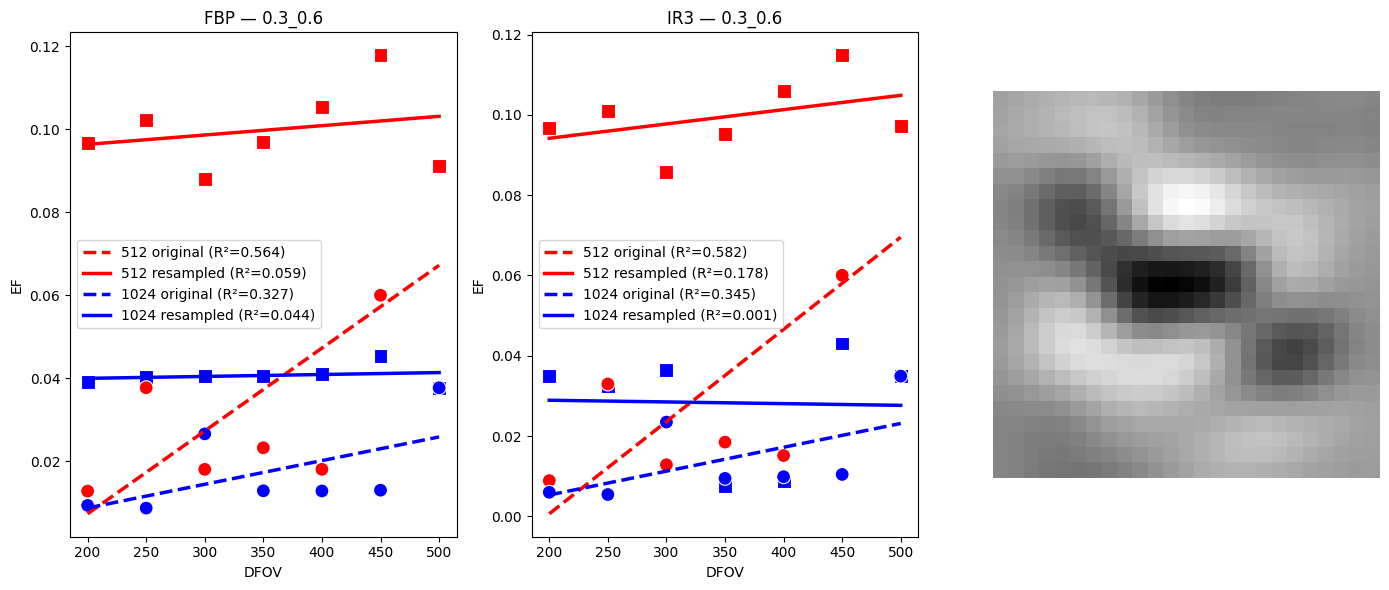

123


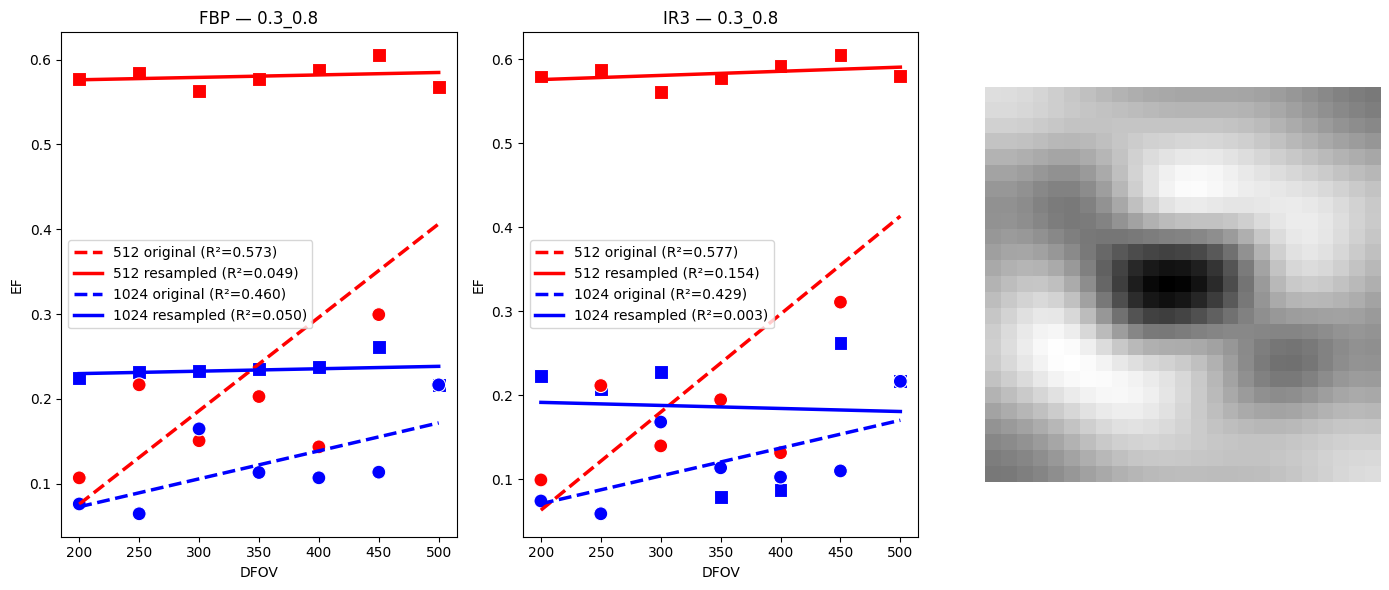

123


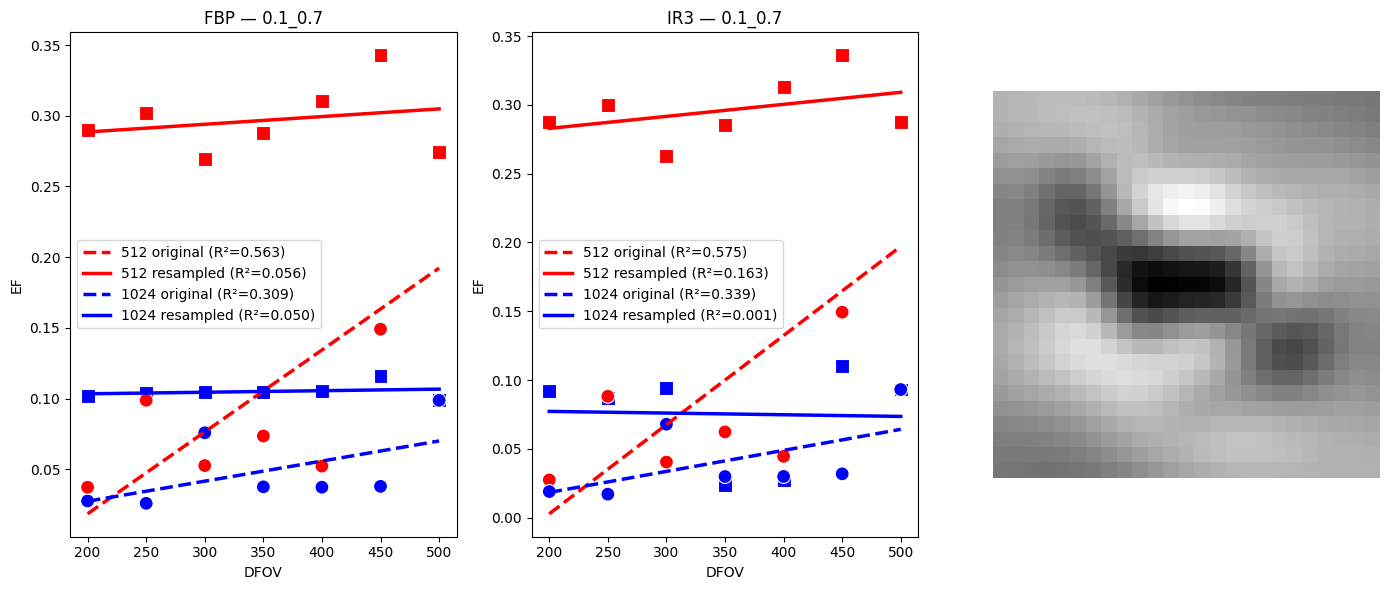

123


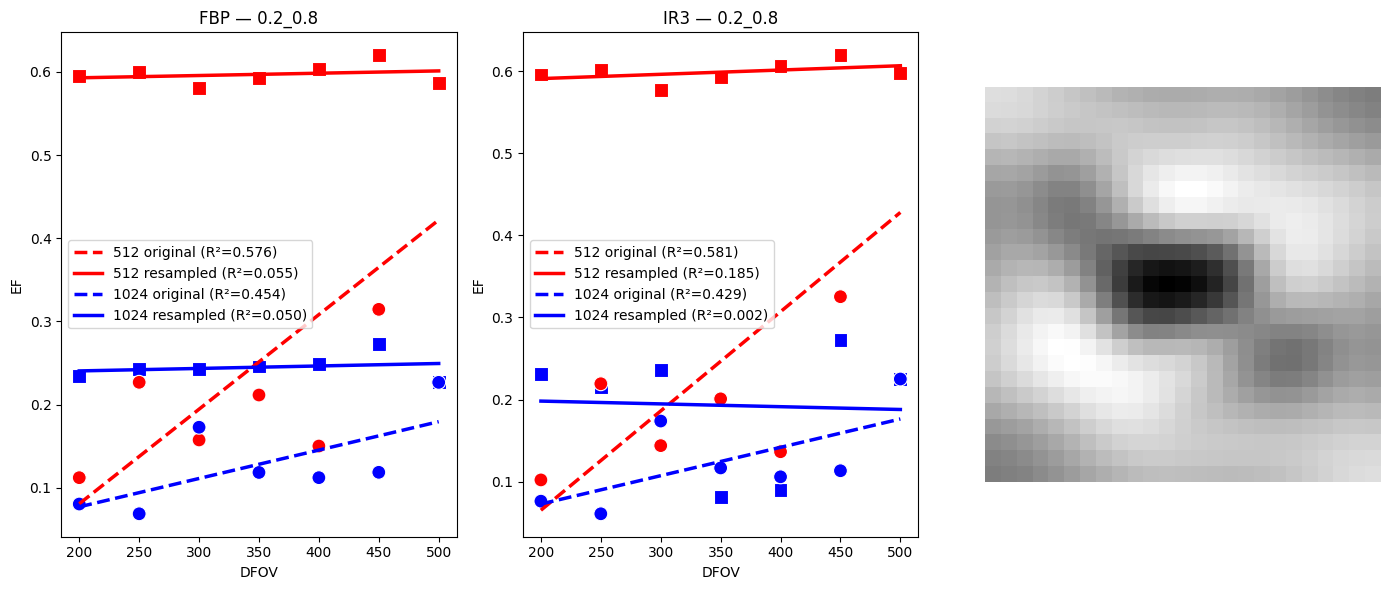

123


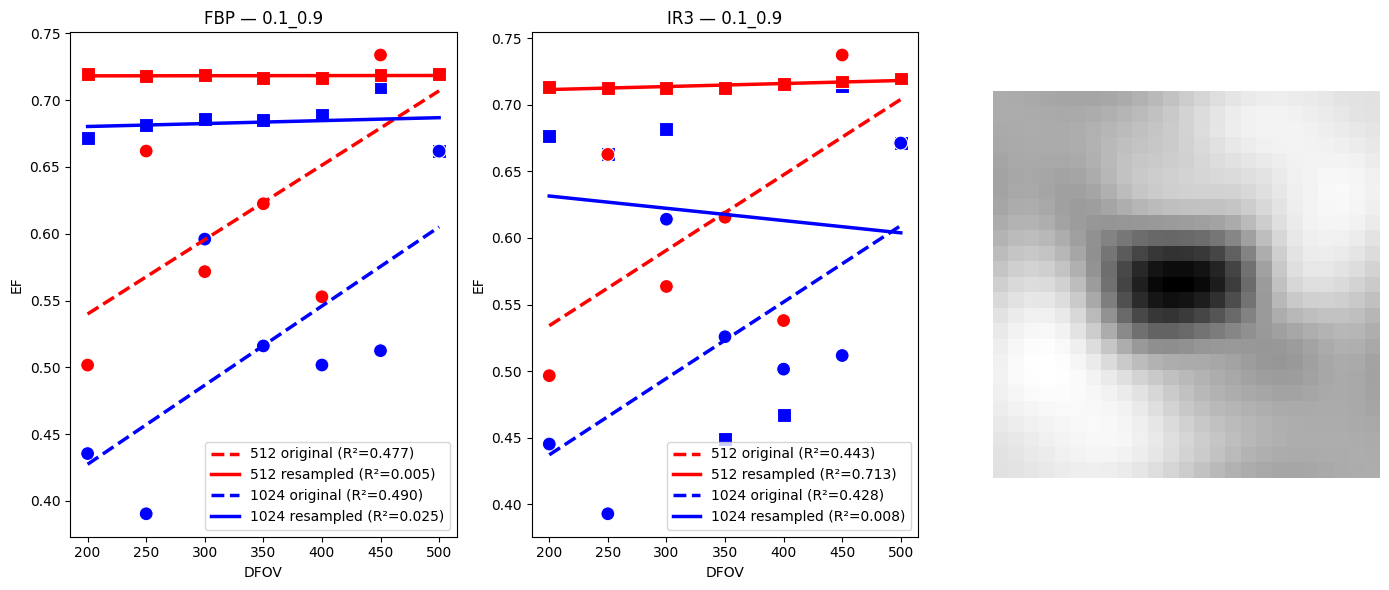

123


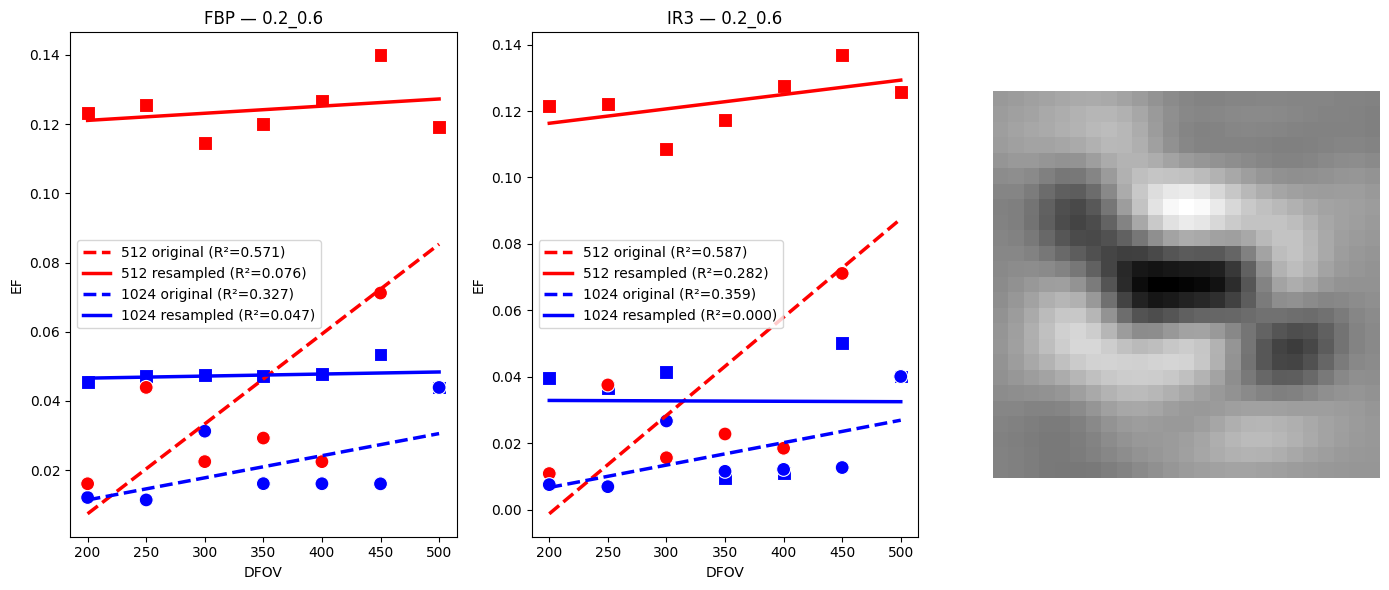

123


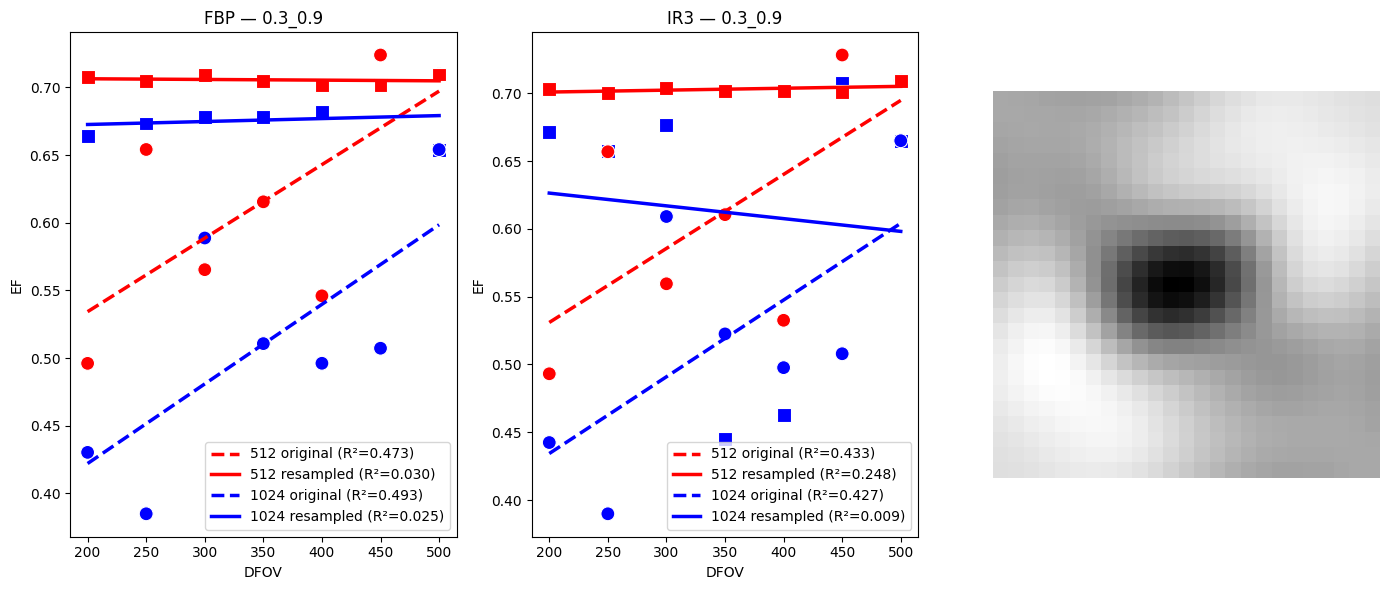

123


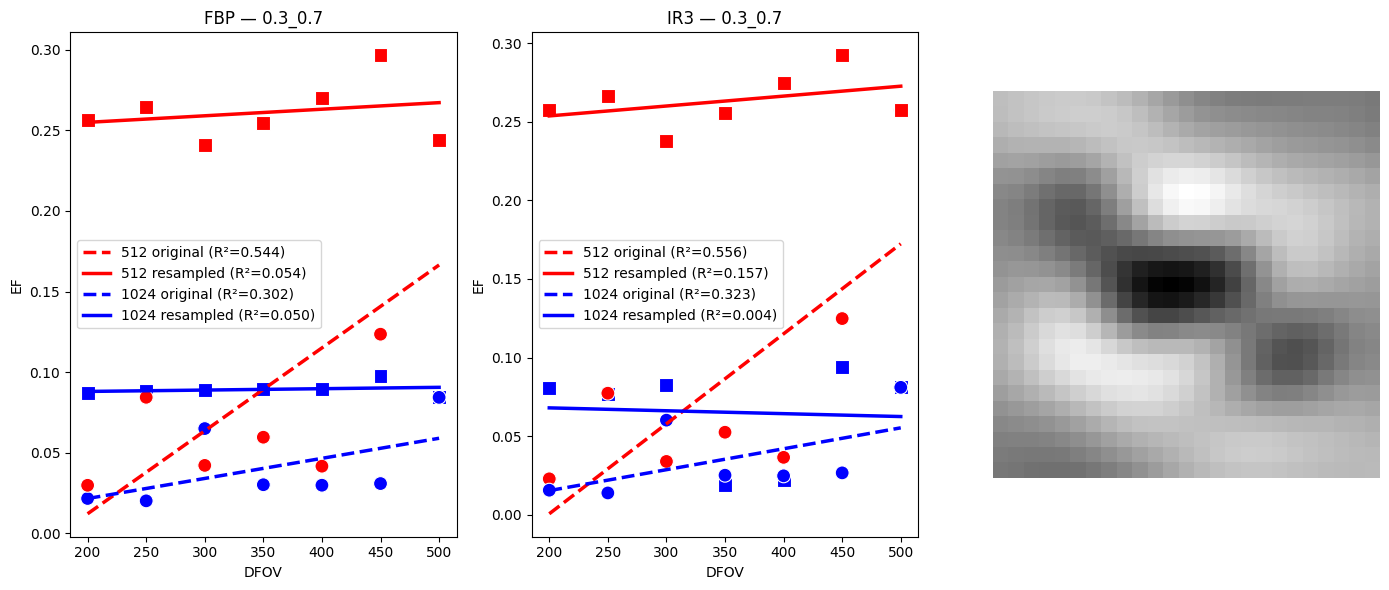

123


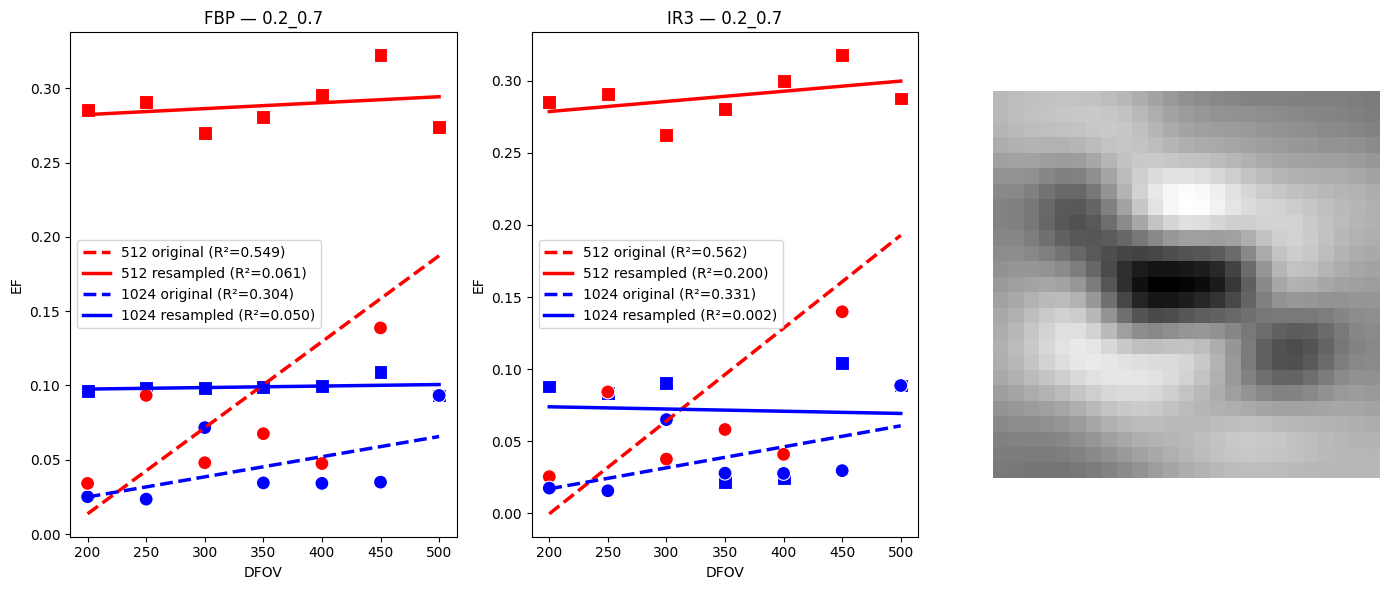

123


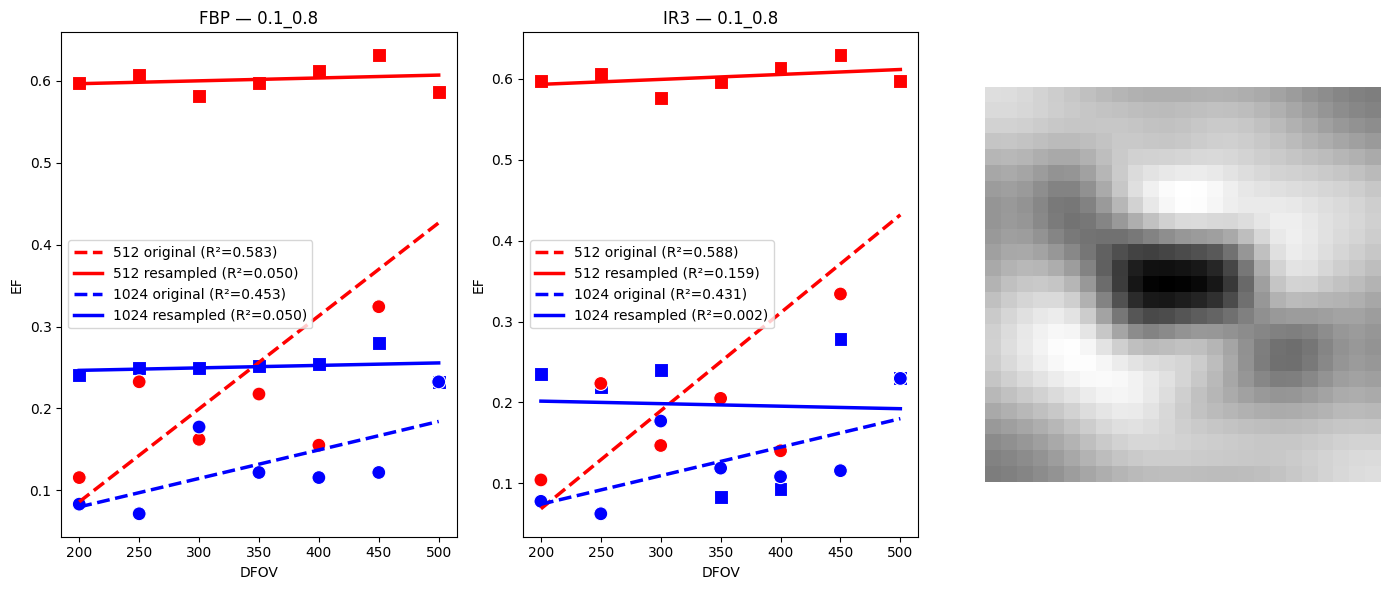

123


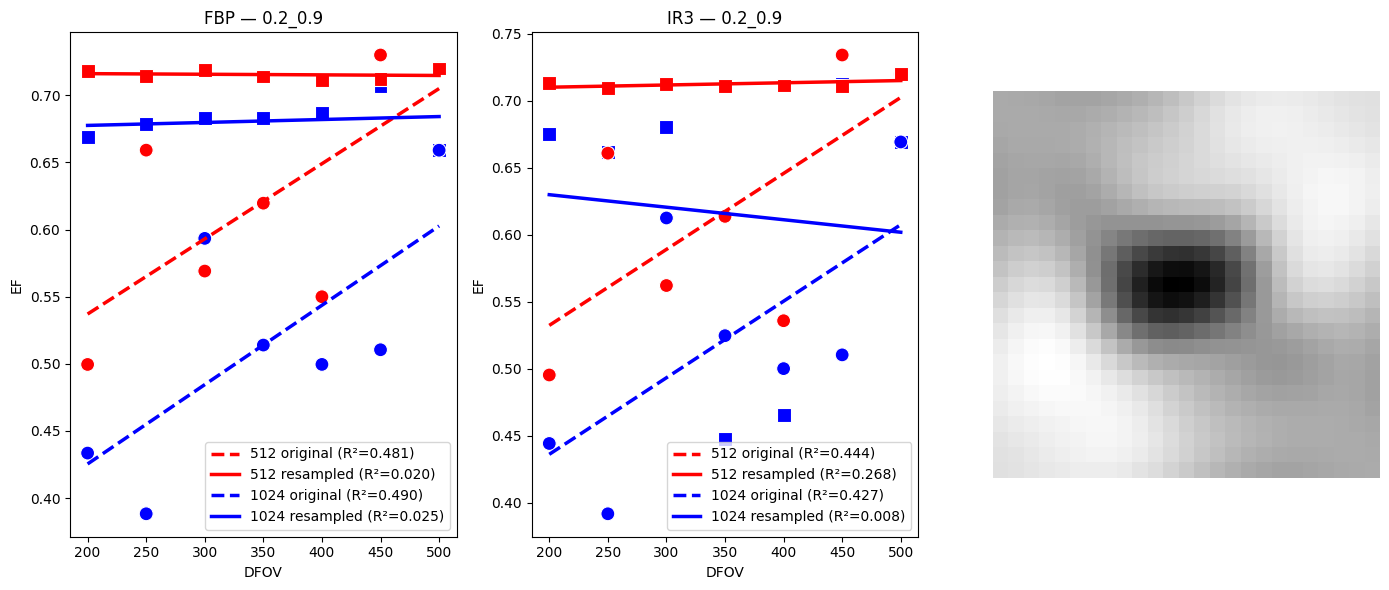

123


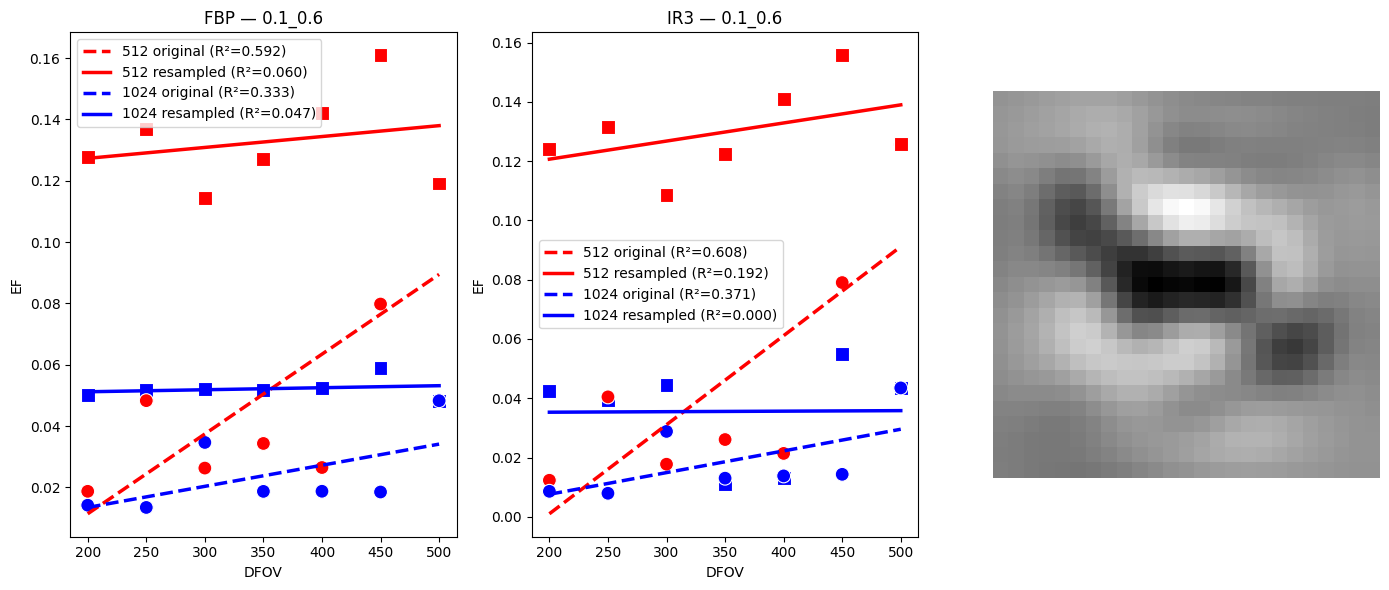

123


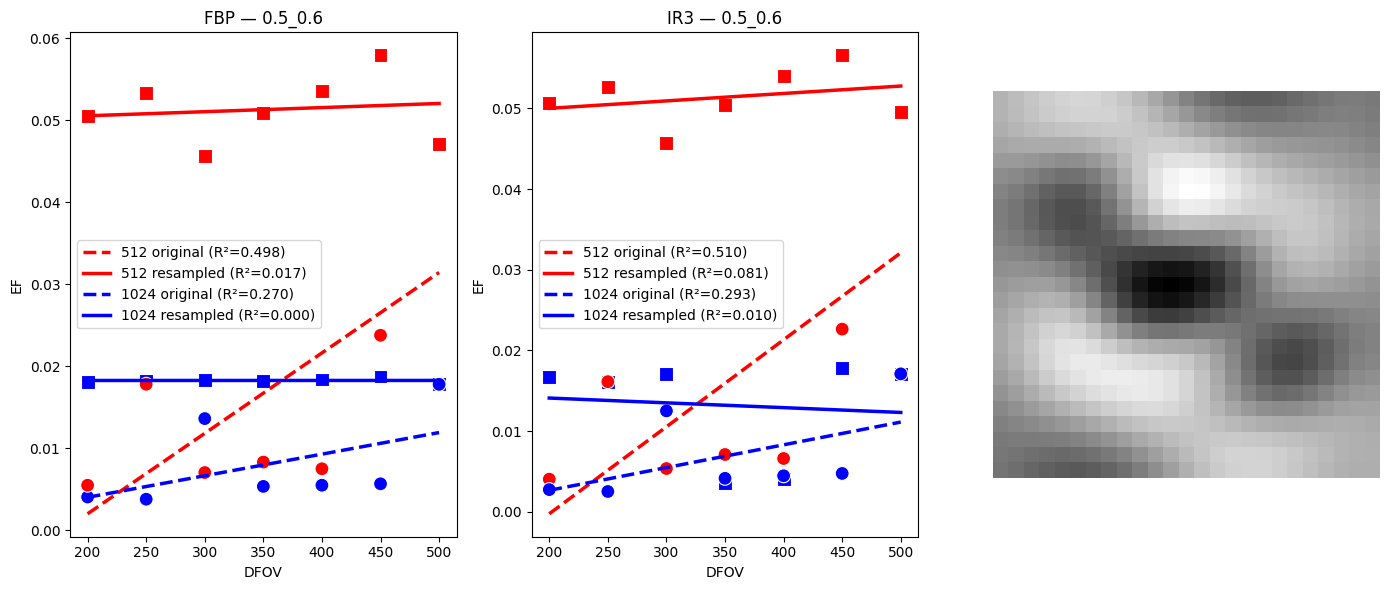

123


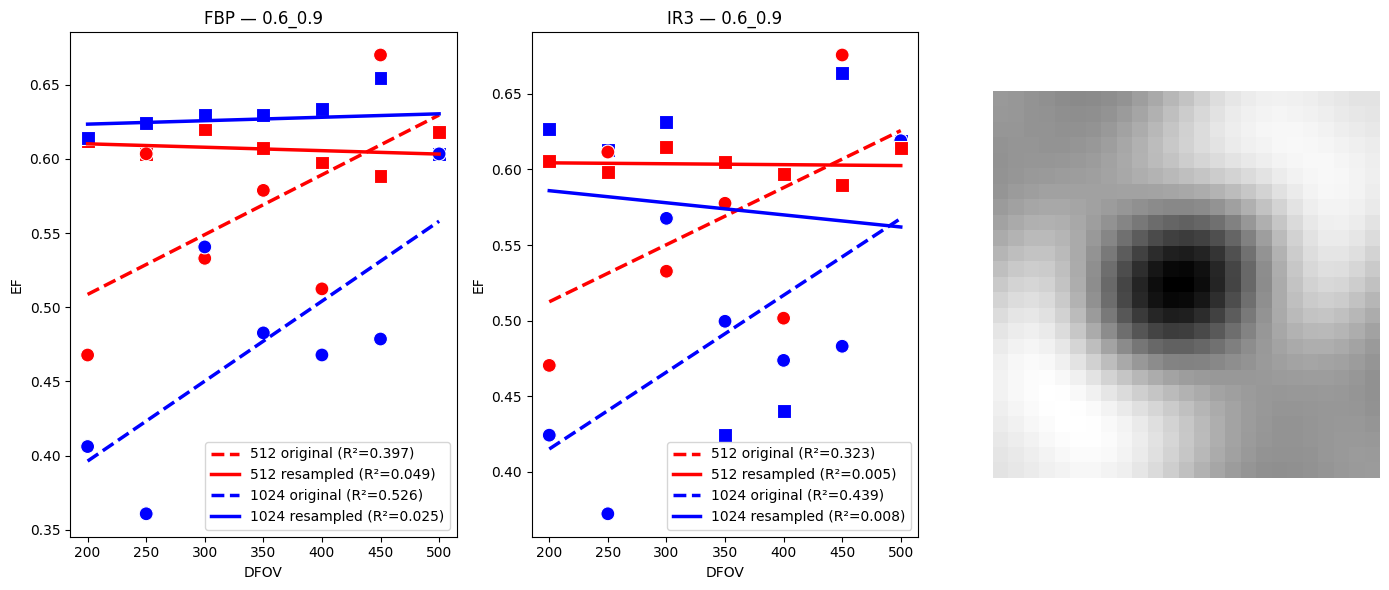

123


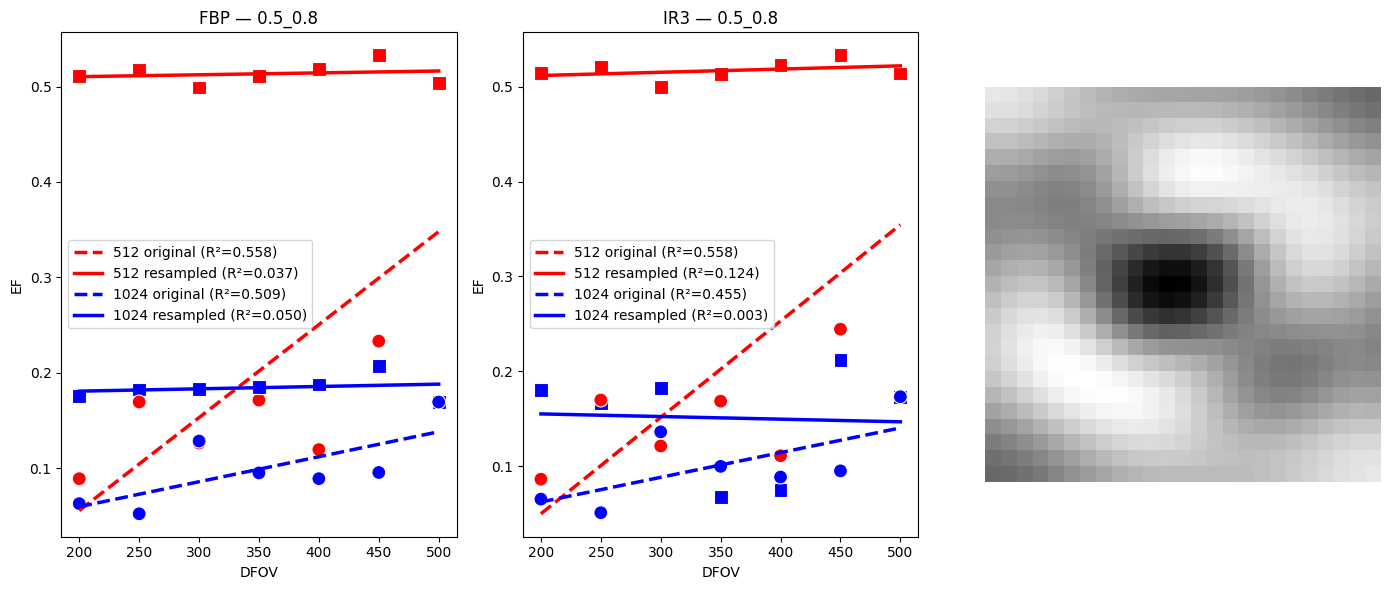

123


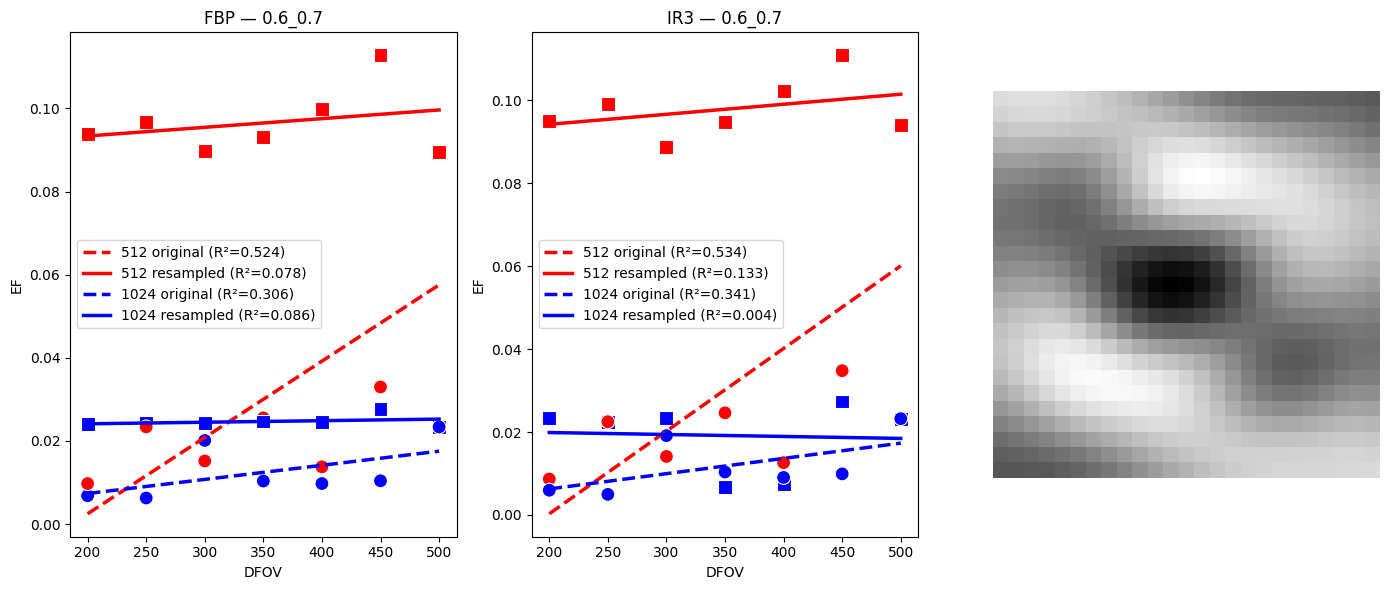

123


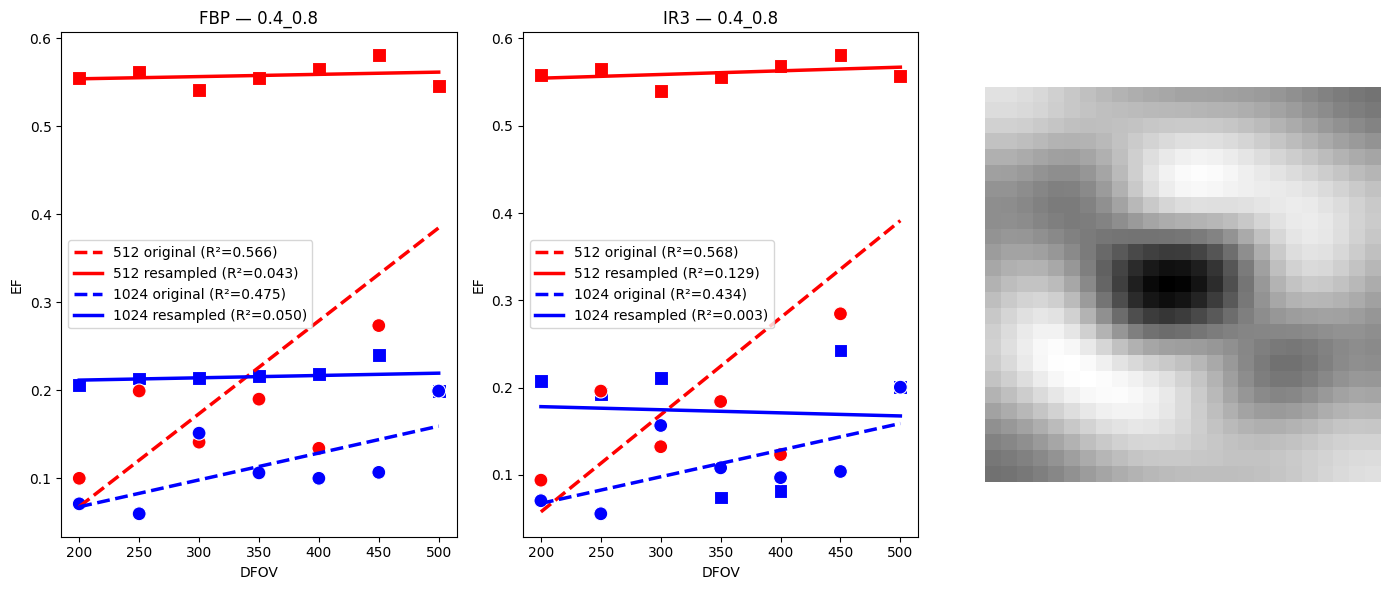

123


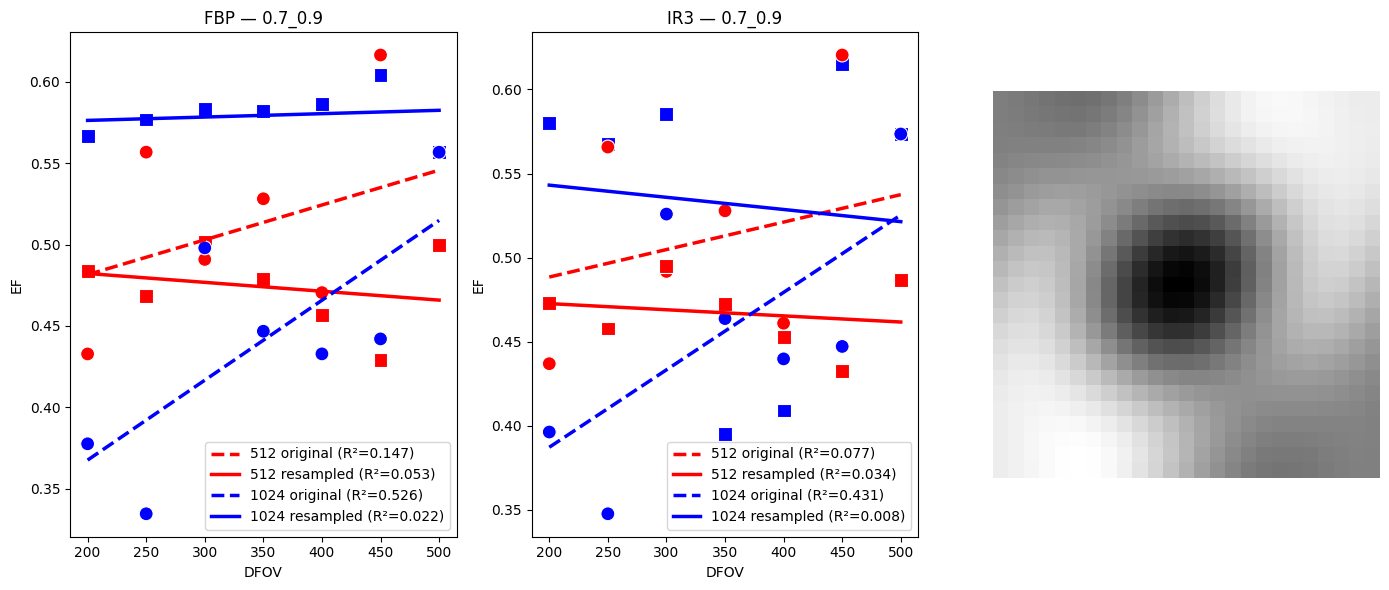

123


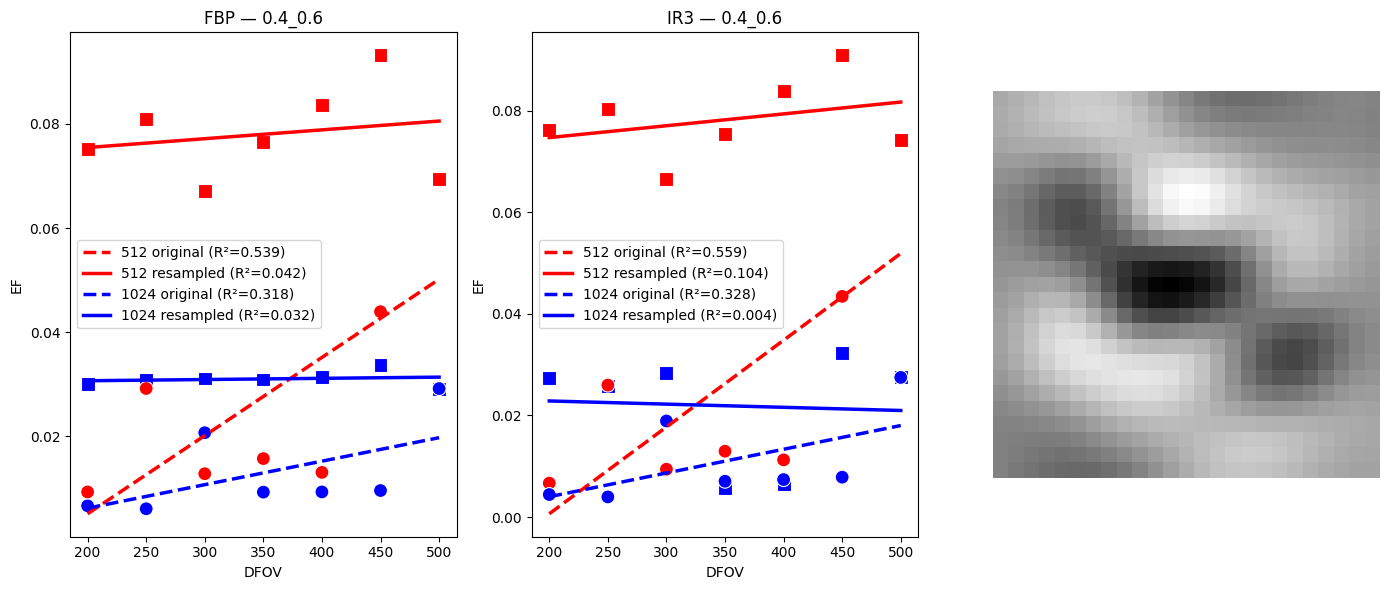

123


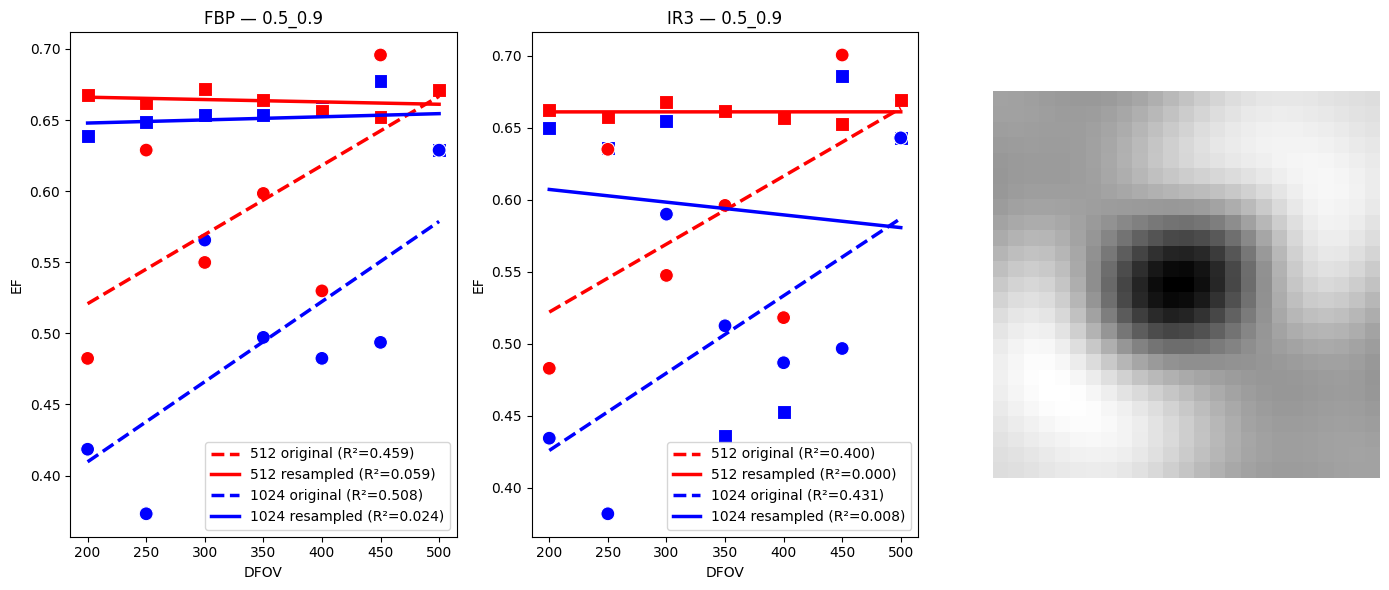

123


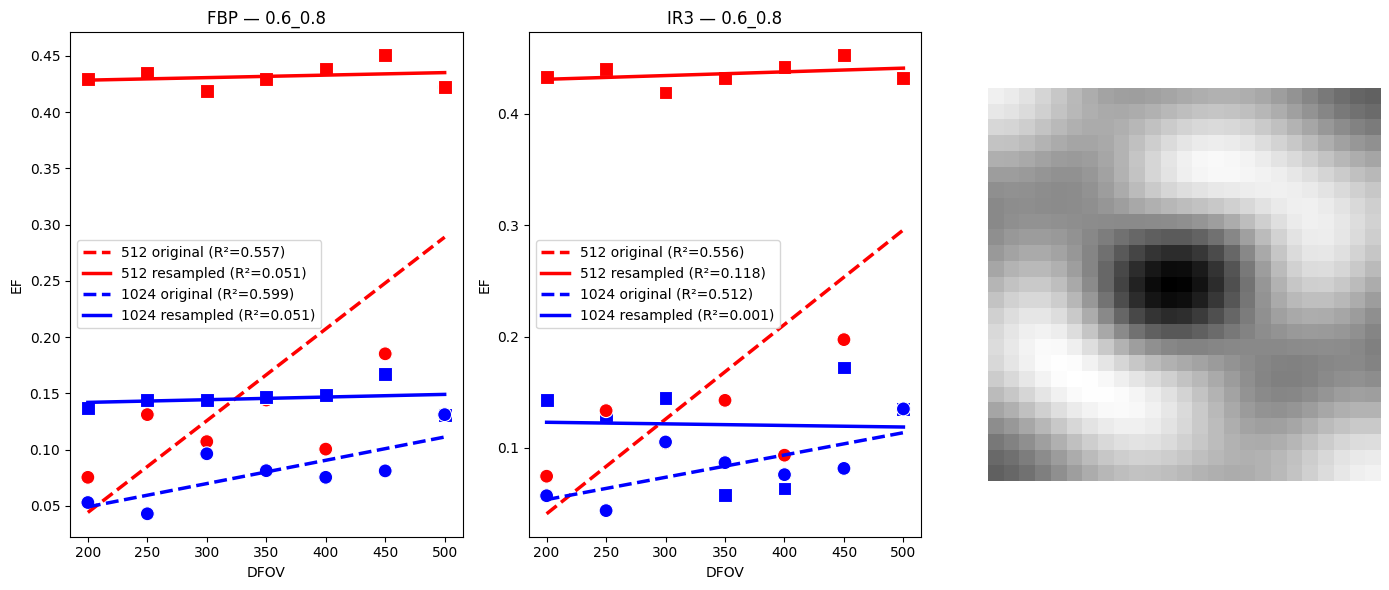

123


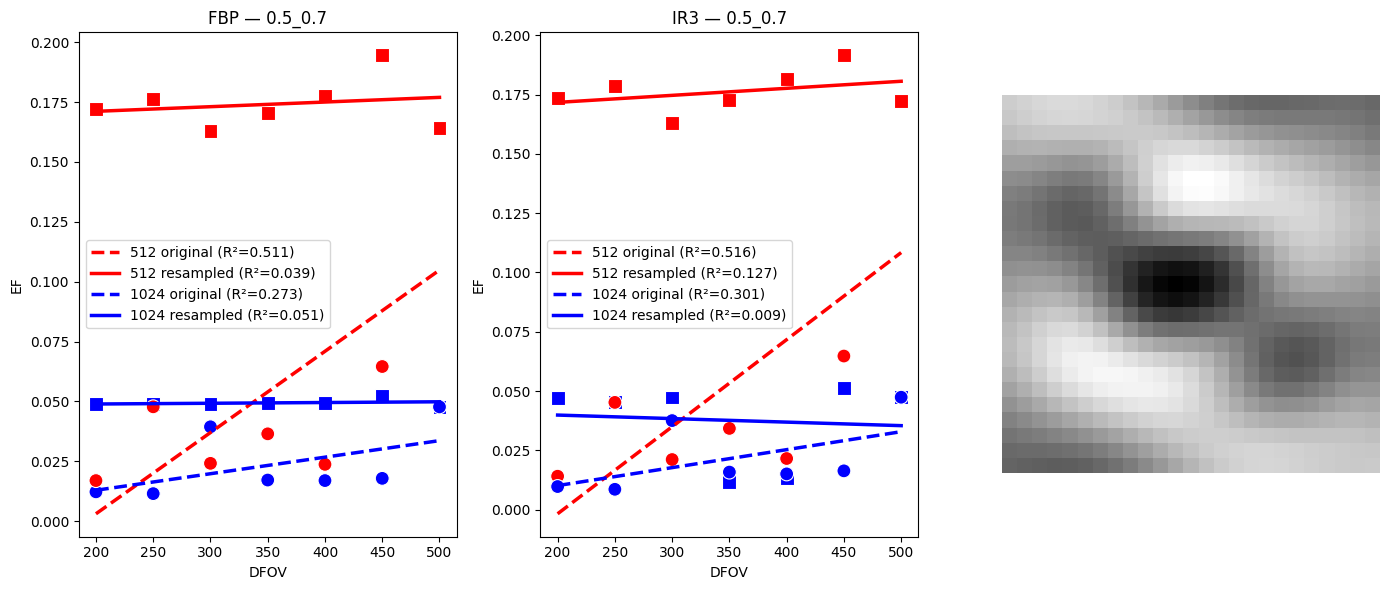

123


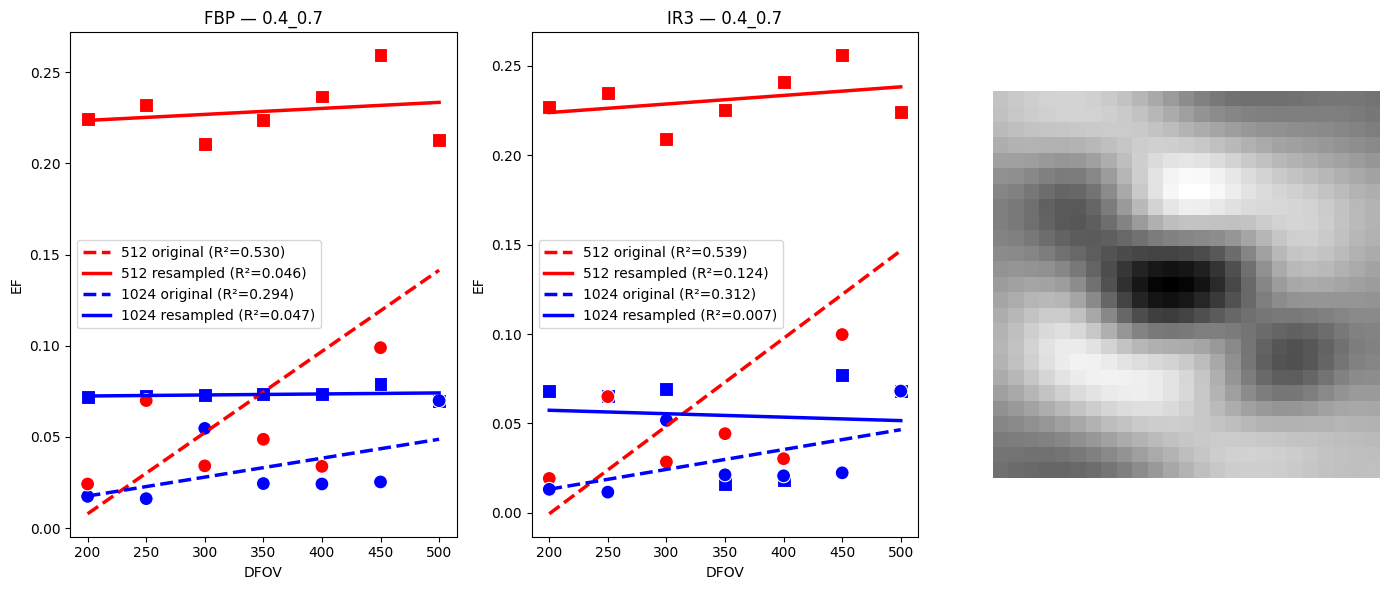

123


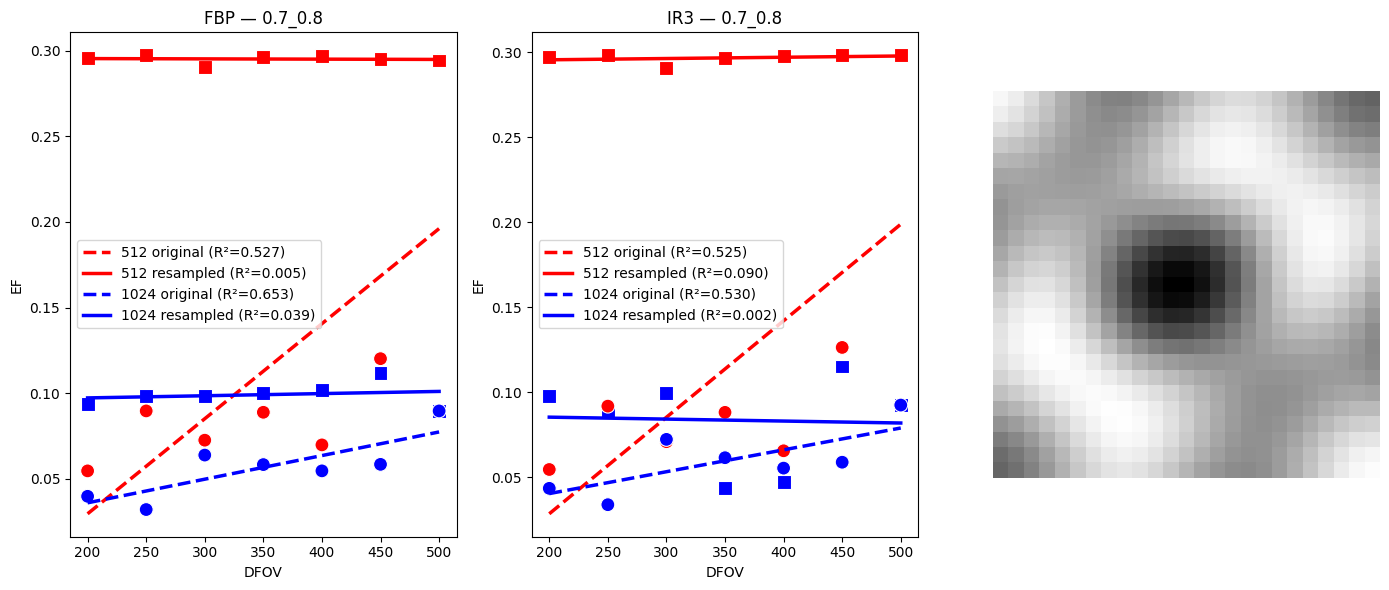

123


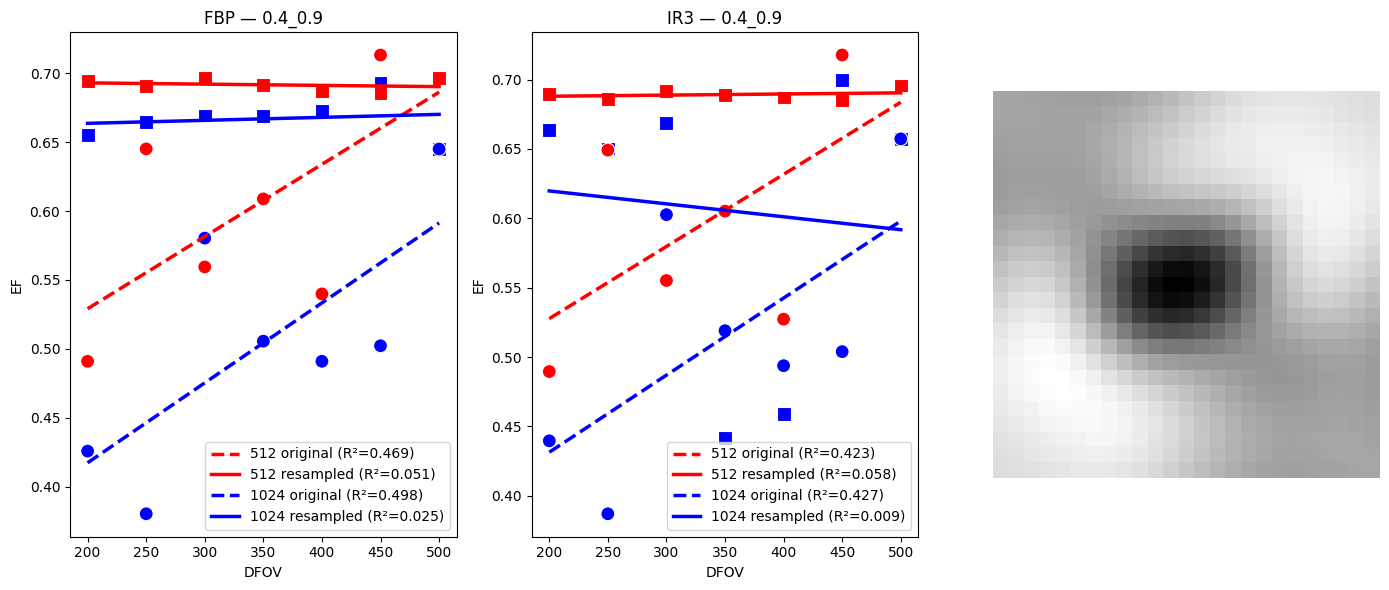

123


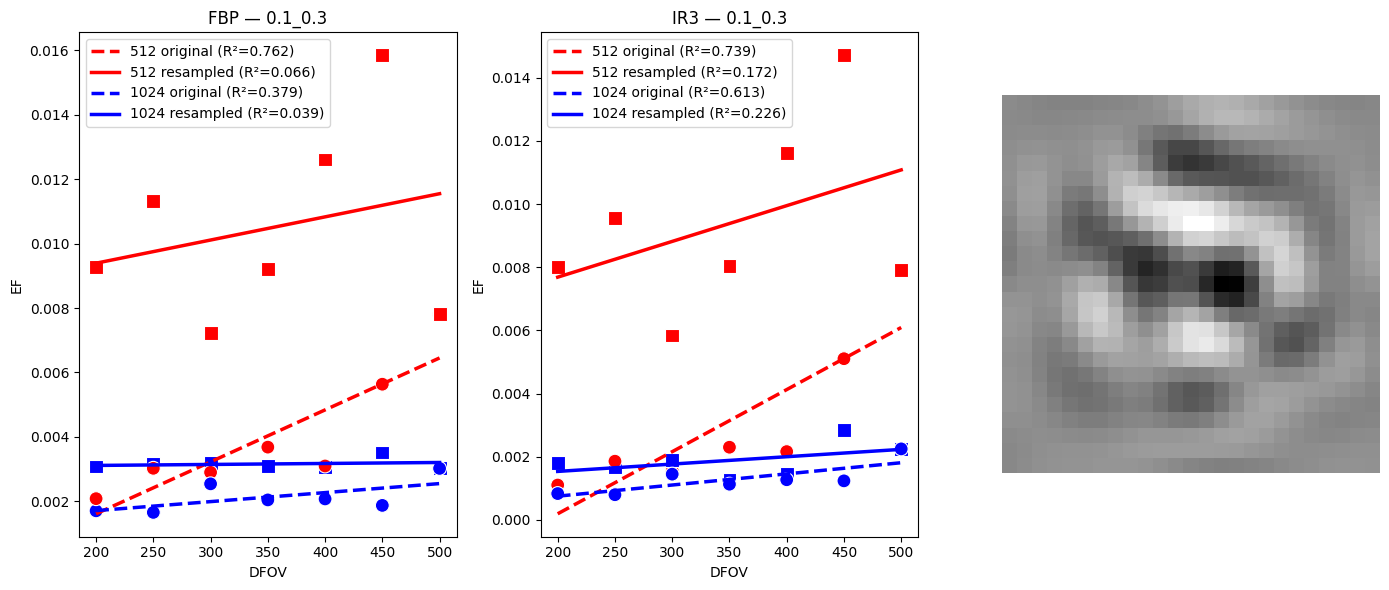

123


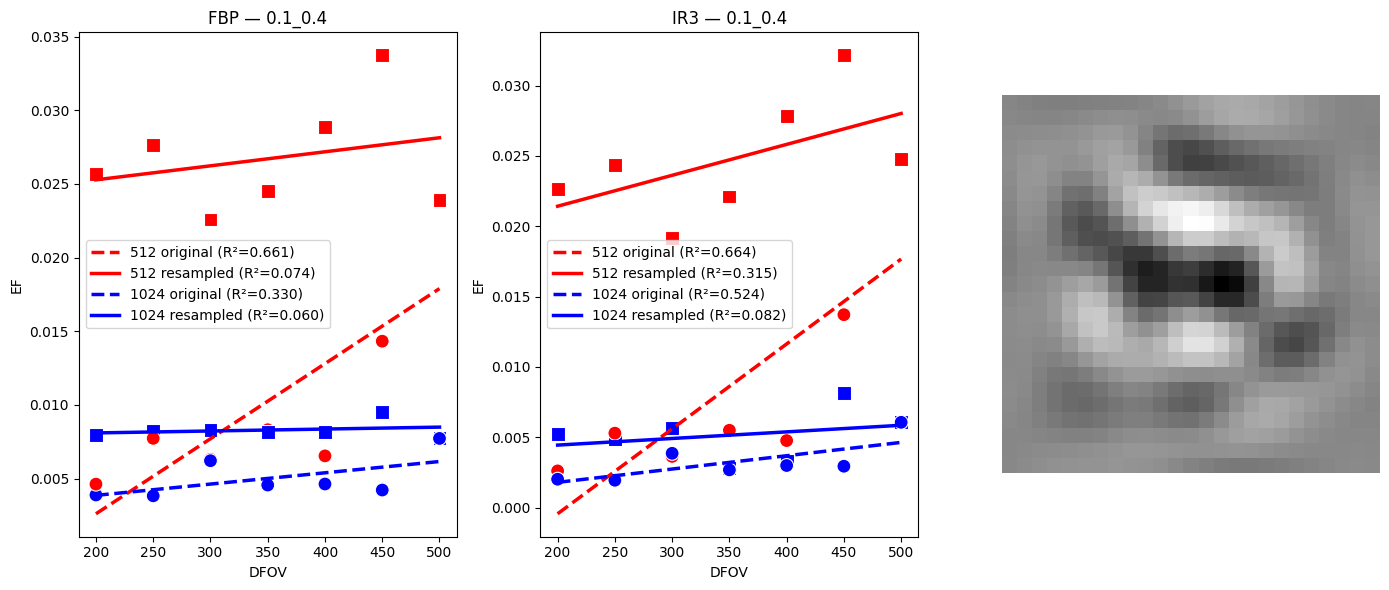

123


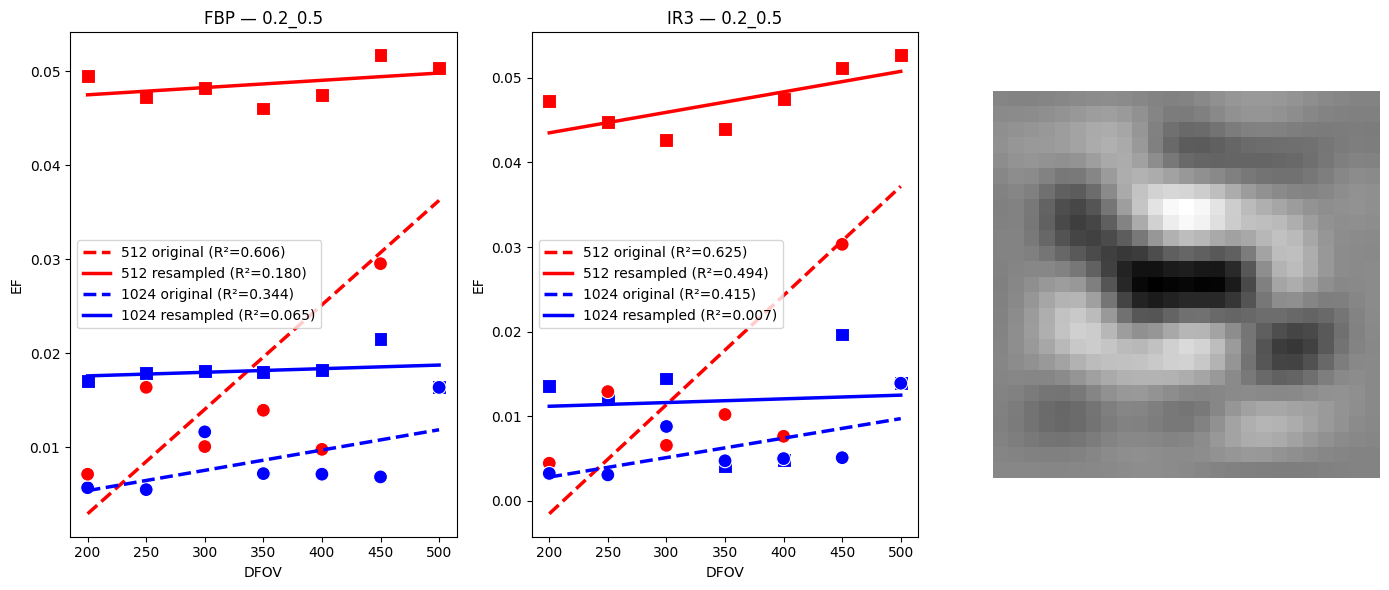

123


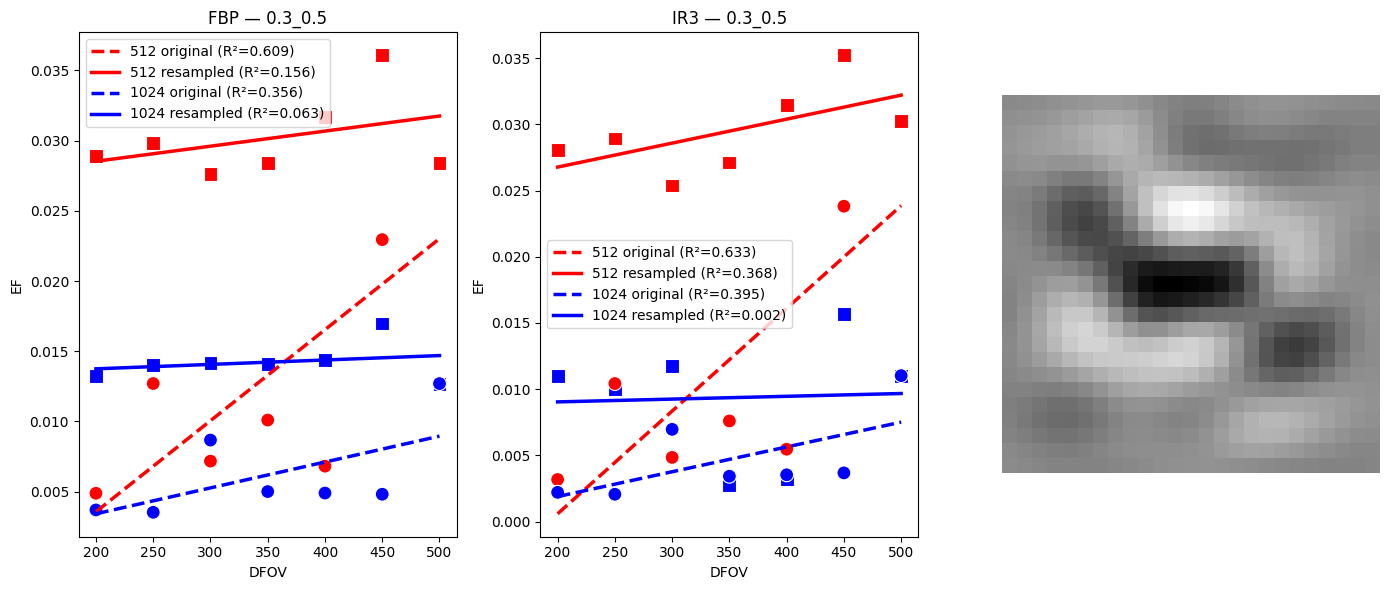

123


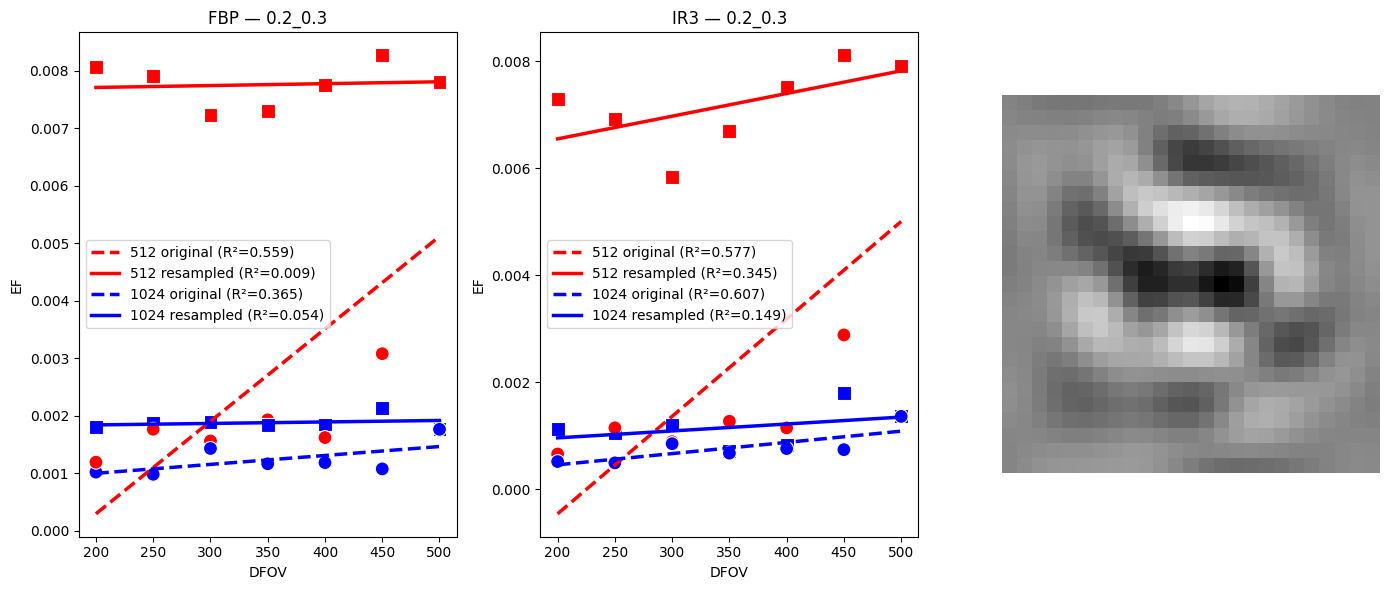

123


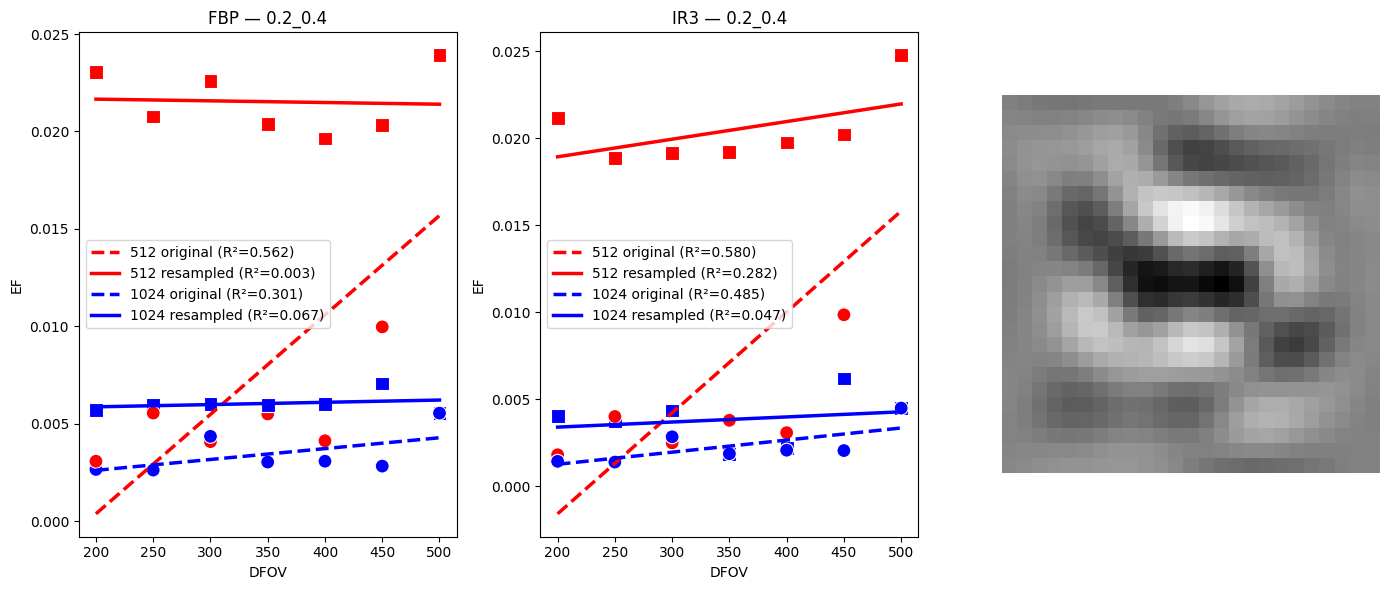

123


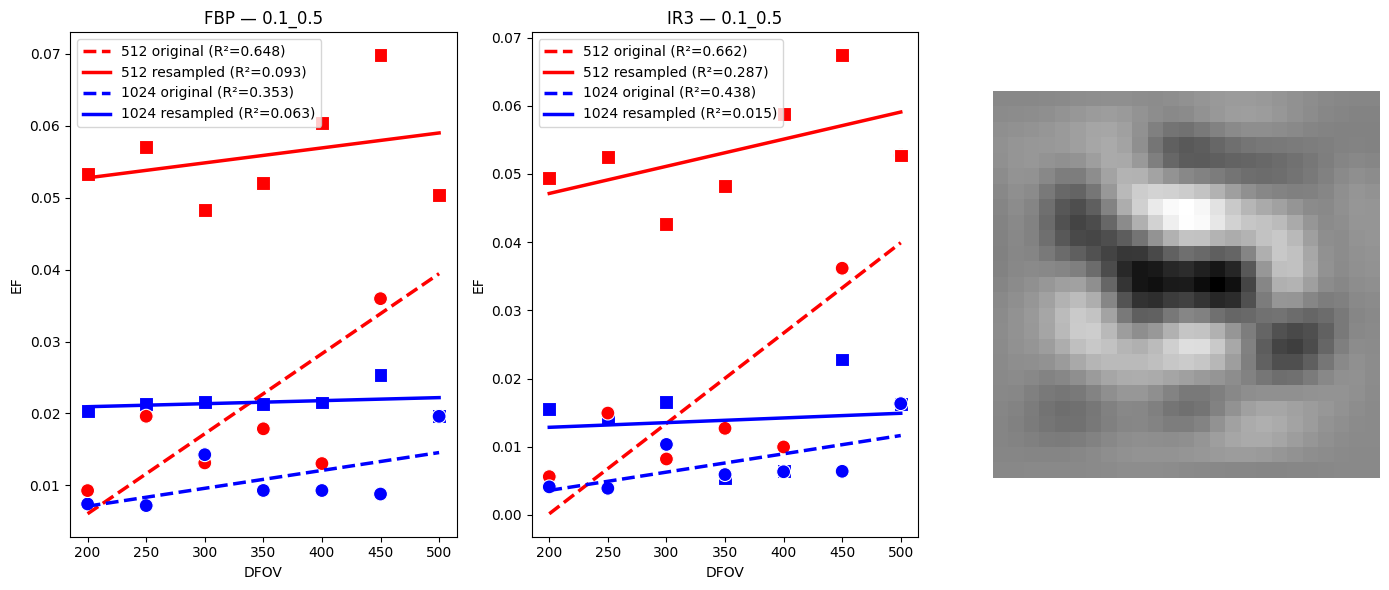

123


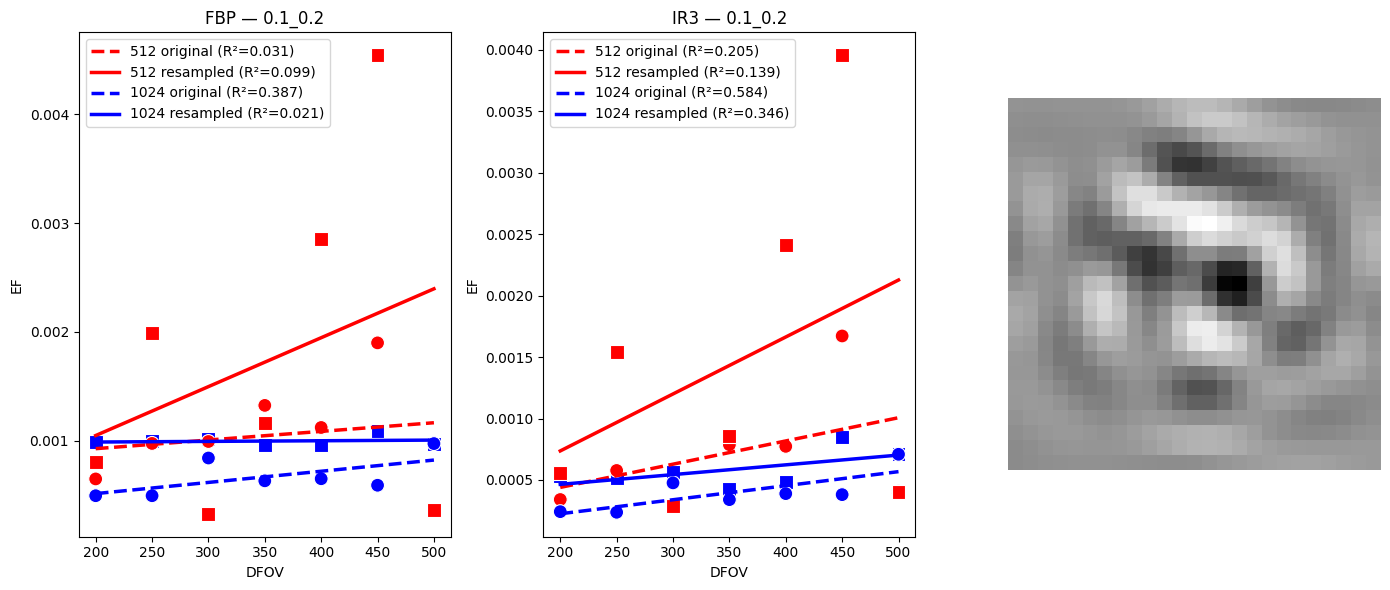

123


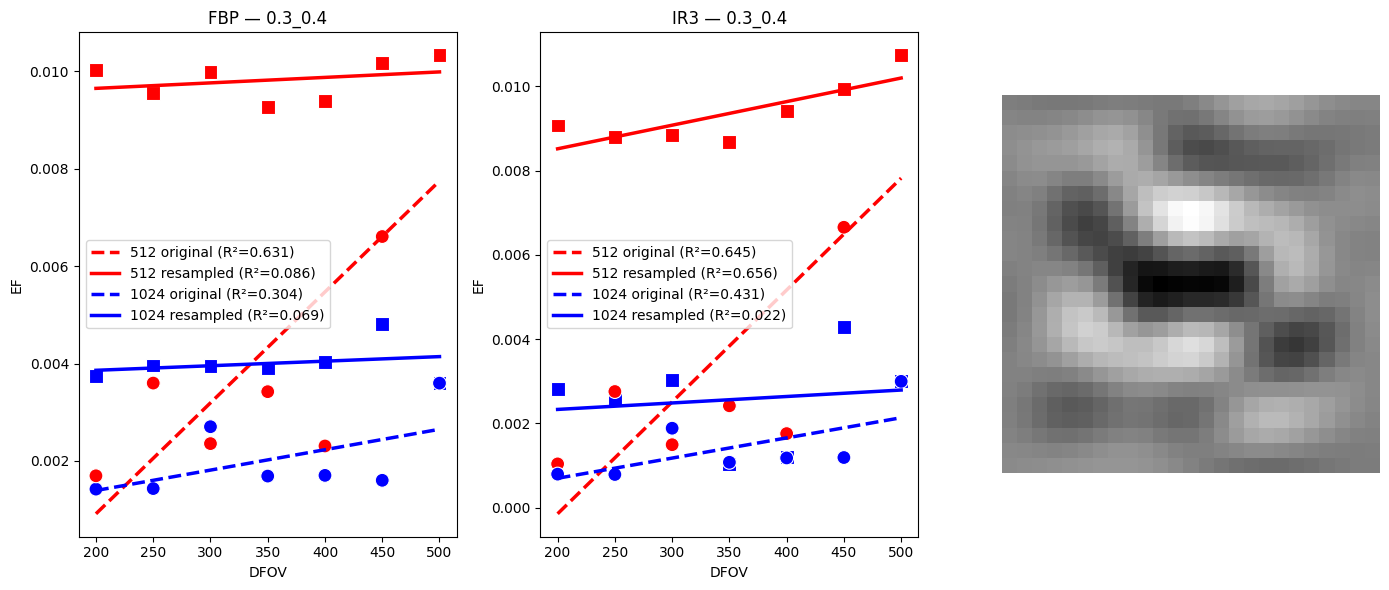

123


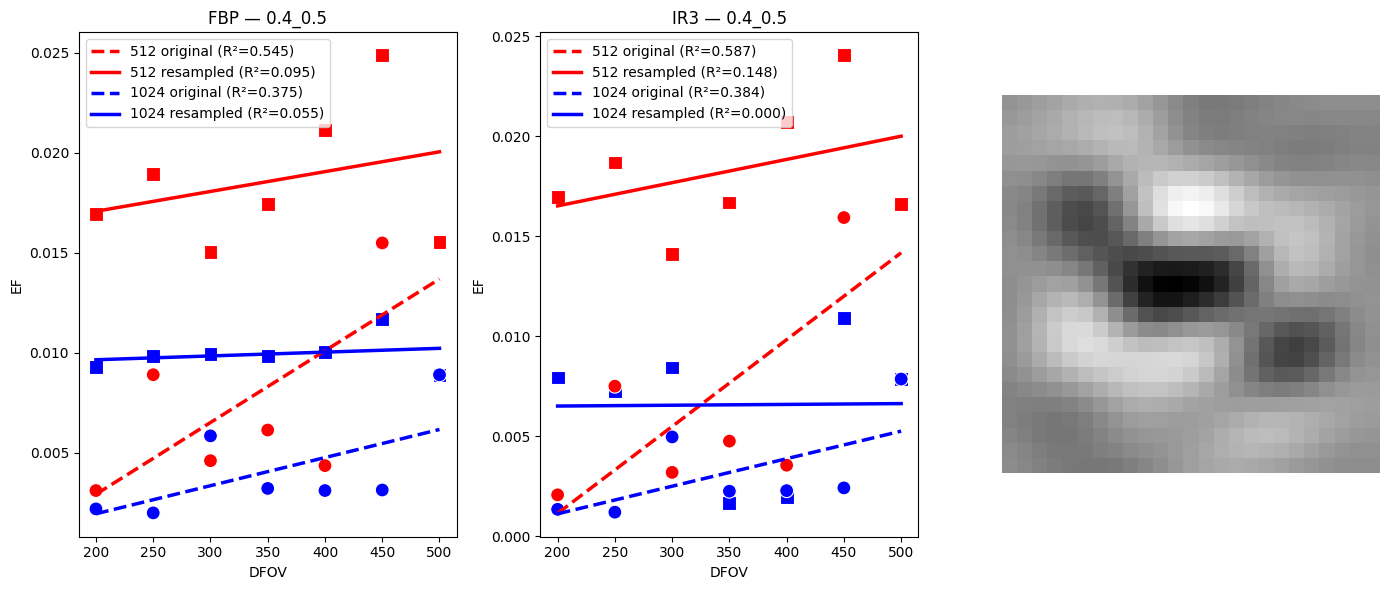

123


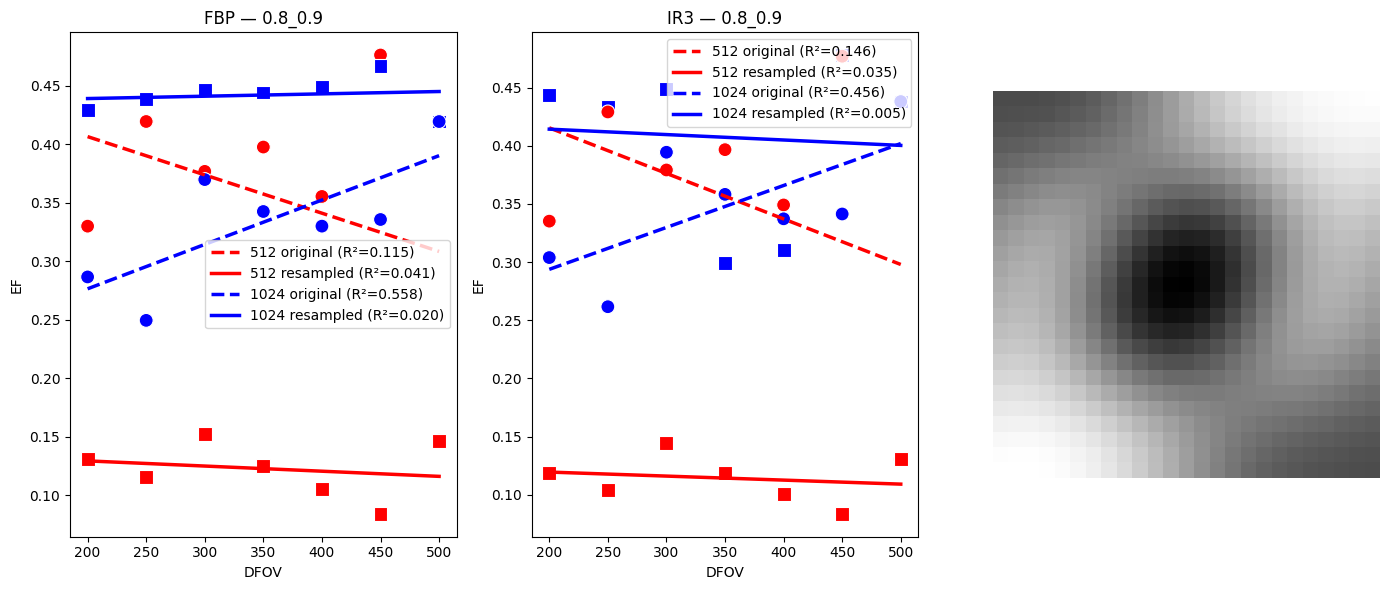

In [56]:

for mod_pair in combined_df["mod_pair"].unique():
    df_sub = combined_df[combined_df["mod_pair"] == mod_pair]

    fig, axes = plt.subplots(1, 3, figsize=(14, 6))
    
    plot_groups = [
        ("FBP", axes[0]),
        ("IR3", axes[1]),
        ("Image", axes[2])
    ]

    colors = {512: "red", 1024: "blue"}

    for ir_type, ax in plot_groups:
        grp_df = df_sub[df_sub["ir"] == ir_type]
        
        if ir_type == "Image":
            print(123)

            img_df = df_sub[
                (df_sub["dfov"] == 300) &
                (df_sub["resampled"] == 0) &
                (df_sub["matrix"] == 1024) &
                (df_sub["ir"] == "FBP")
            ]

            if len(img_df) > 0:
                img = sitk.ReadImage(img_df["image_path"])
                ax.imshow(sitk.GetArrayFromImage(img)[0], cmap="gray")
                ax.axis("off")

            continue

        grp_df = df_sub[df_sub["ir"] == ir_type]

        if len(grp_df) == 0:
            continue

        sns.scatterplot(
            data=grp_df,
            x="dfov",
            y="ef",
            hue="matrix",
            style="resampled",
            markers={0: "o", 1: "s"},
            palette=colors,
            s=100,
            ax=ax,
            legend=False
        )

        for (matrix, resampled_flag), df_r in grp_df.groupby(["matrix", "resampled"]):

            if df_r["dfov"].nunique() > 1:
                x = df_r["dfov"].values
                y = df_r["ef"].values

                # quadratic fit
                coeffs = np.polyfit(x, y, 1)
                poly = np.poly1d(coeffs)
                y_pred = poly(x)

                # compute R^2
                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - np.mean(y)) ** 2)
                r2 = 1 - ss_res / ss_tot

                sns.regplot(
                    data=df_r,
                    x="dfov",
                    y="ef",
                    scatter=False,
                    order=1,
                    ci=None,
                    color=colors[matrix],
                    line_kws={
                        "linestyle": "--" if resampled_flag == 0 else "-",
                        "linewidth": 2.5
                    },
                    label=f"{matrix} {'resampled' if resampled_flag else 'original'} (R²={r2:.3f})",
                    ax=ax
                )

        ax.set_title(f"{ir_type} — {mod_pair}")
        ax.set_xlabel("DFOV")
        ax.set_ylabel("EF")
        ax.legend()

    plt.tight_layout()
    plt.show()